# BÀI 1: Biểu diễn dữ liệu thành ma trận & độ tương đồng

# 1.BIẾN DỮ LIỆU THÀNH MA TRẬN

- Sử dụng tập dữ liệu gồm **8 ảnh**.
- Mỗi ảnh có kích thước **250 × 200**.

### Vì sao cần trải phẳng (Flatten)?

- Ảnh xám có dạng ma trận 2 chiều `(H, W)`.
- Các thuật toán xử lý dữ liệu thường yêu cầu đầu vào là vector đặc trưng 1 chiều.
- Flatten giúp chuyển ma trận ảnh thành một vector chứa toàn bộ giá trị pixel.
- Mỗi pixel được xem là một **feature (đặc trưng)**.

### Kết quả

```python
print(X.shape) = (8, 50000)
Trong đó: 
- n_samples = 8: số lượng ảnh
- n_features = 50000: số pixel của mỗi ảnh

In [3]:
from PIL import Image
import numpy as np
# Đọc ảnh và chuyển sang ảnh xám
img1 = np.array(Image.open(r"C:\Users\AD\Downloads\image_1.jpg").convert("L"))
img2 = np.array(Image.open(r"C:\Users\AD\Downloads\image_2.jpg").convert("L"))
img3 = np.array(Image.open(r"C:\Users\AD\Downloads\image_3.jpg").convert("L"))
img4 = np.array(Image.open(r"C:\Users\AD\Downloads\image_4.jpg").convert("L"))
img5 = np.array(Image.open(r"C:\Users\AD\Downloads\image_5.jpg").convert("L"))
img6 = np.array(Image.open(r"C:\Users\AD\Downloads\image_6.jpg").convert("L"))
img7 = np.array(Image.open(r"C:\Users\AD\Downloads\image_7.jpg").convert("L"))
img8 = np.array(Image.open(r"C:\Users\AD\Downloads\image_8.jpg").convert("L")) 
# Trải phẳng (?) và ghép thành ma trận
X = np.array([
    img1.flatten(),
    img2.flatten(),
    img3.flatten(),
    img4.flatten(),
    img5.flatten(),
    img6.flatten(),
    img7.flatten(),
    img8.flatten()
])
print(X.shape)
#print(X[0]) vector gồm 50000 giá trị pixel (HxW) của ảnh 1

(8, 50000)


# 2. PHÉP TOÁN CƠ BẢN

In [4]:
# Tính vector trung bình theo cột
mean_vector = np.mean(X, axis=0)
print(mean_vector)
print(mean_vector.shape) # vector trung bình có 50000 giá trị pixel (HxW) của ảnh trung bình

[ 89.375  92.75   92.375 ...  99.375 102.    103.25 ]
(50000,)


In [5]:
print(f"Shape X trước quy tắc broadcast: {X.shape}\n", X)
print(f"Vector trung bình theo cột: {mean_vector.shape}\n", mean_vector)
# Trừ trung bình (Broadcast)
X_centered = X - mean_vector
print(f"-> Shape X sau quy tắc broadcast: {X_centered.shape}\n", X_centered)

Shape X trước quy tắc broadcast: (8, 50000)
 [[212 213 213 ... 217 222 223]
 [  0   0   0 ...   0   0   0]
 [249 249 249 ... 150 162 171]
 ...
 [ 44  57  51 ... 128 130 131]
 [ 14  14  14 ...  24  34  32]
 [108 117 118 ... 106 107 113]]
Vector trung bình theo cột: (50000,)
 [ 89.375  92.75   92.375 ...  99.375 102.    103.25 ]
-> Shape X sau quy tắc broadcast: (8, 50000)
 [[ 122.625  120.25   120.625 ...  117.625  120.     119.75 ]
 [ -89.375  -92.75   -92.375 ...  -99.375 -102.    -103.25 ]
 [ 159.625  156.25   156.625 ...   50.625   60.      67.75 ]
 ...
 [ -45.375  -35.75   -41.375 ...   28.625   28.      27.75 ]
 [ -75.375  -78.75   -78.375 ...  -75.375  -68.     -71.25 ]
 [  18.625   24.25    25.625 ...    6.625    5.       9.75 ]]


# 3. COSINE SIMILARITY

**Hướng logic:** Vector hóa dữ liệu → Chuẩn hóa theo hàng → Broadcasting → Nhân ma trận → Ma trận độ tương đồng

---

## 3.1 Vector hóa dữ liệu

Đưa toàn bộ dữ liệu thành ma trận, mỗi hàng là một vector đặc trưng.

```python
X.shape = (8, 50000)  # 8 ảnh, mỗi ảnh flatten thành vector 50.000 chiều
```

---

## 3.2 Chuẩn hóa theo hàng (L2 normalization)

Cosine similarity đo **góc** giữa hai vector, không quan tâm đến độ lớn.
Ta chuẩn hóa từng hàng về độ dài 1:

$$X_{\text{norm}} = \frac{X}{\|X\|_2}$$

Khi đó tích vô hướng của hai unit vector chính là cosine similarity:

$$\cos(x_i, y_j) = x_i \cdot y_j \quad \text{(vì } \|x_i\| = \|y_j\| = 1\text{)}$$

```python
norm_X = np.linalg.norm(X, axis=1, keepdims=True)  # shape (n, 1)
X_norm = X / norm_X                                 # shape (n, d)
```

> `keepdims=True` giữ chiều `(n, 1)` để broadcast đúng với `X` shape `(n, d)`.

---

## 3.3 Broadcasting

NumPy tự động mở rộng kích thước mảng để thực hiện phép toán giữa các mảng có
---

## 3.4 Nhân ma trận

Nhân `X_norm @ Y_norm.T` tính đồng thời toàn bộ `n × m` cặp dot product.

| Trường hợp | Công thức | Shape kết quả |
|---|---|---|
| Chỉ có `X` | `X_norm @ X_norm.T` | `(n, n)` |
| Có cả `X` và `Y` | `X_norm @ Y_norm.T` | `(n, m)` |

---

## 3.5 Ma trận độ tương đồng

`S[i, j]` là cosine similarity giữa vector `x_i` và `y_j`.

| Giá trị `S[i, j]` | Ý nghĩa |
|---|---|
| `= 1` | Cùng hướng — hoàn toàn giống nhau |
| `≈ 0` | Vuông góc — không liên quan |
| `= -1` | Ngược hướng — hoàn toàn trái ngược |

> Khi `Y = X`, đường chéo chính `S[i, i]` luôn bằng `1` (vector so với chính nó).
> Để đánh giá tương đồng, ta xem các phần tử **ngoài đường chéo**.

In [6]:
def cosine_similarity(X, Y = None):
    # --1. Vector hóa dữ liệu --
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float) if Y is not None else X
    # --2. Chuẩn hóa theo hàng --
    norm_X = np.linalg.norm(X, axis=1, keepdims=True)
    norm_Y = np.linalg.norm(Y, axis=1, keepdims=True)
    # Tránh chia cho 0
    norm_x = np.where(norm_X == 0, 1e-10, norm_X)
    norm_y = np.where(norm_Y == 0, 1e-10, norm_Y)

    X_normalized = X / norm_x
    Y_normalized = Y / norm_y
    # --3 & 4.Broadcast & Nhân ma trận --
    similarity_matrix = np.dot(X_normalized, Y_normalized.T)   
    return similarity_matrix
similarity_matrix = cosine_similarity(X)
print(similarity_matrix)


[[1.         0.52705713 0.79307852 0.78140556 0.78462937 0.83941078
  0.83085125 0.79904351]
 [0.52705713 1.         0.56875387 0.50119382 0.54444402 0.57834808
  0.58871113 0.62485518]
 [0.79307852 0.56875387 1.         0.80570237 0.66638991 0.74544847
  0.79148341 0.77110638]
 [0.78140556 0.50119382 0.80570237 1.         0.66207919 0.74598246
  0.77246615 0.70780834]
 [0.78462937 0.54444402 0.66638991 0.66207919 1.         0.75963892
  0.78341286 0.75396442]
 [0.83941078 0.57834808 0.74544847 0.74598246 0.75963892 1.
  0.83107601 0.80641104]
 [0.83085125 0.58871113 0.79148341 0.77246615 0.78341286 0.83107601
  1.         0.80333193]
 [0.79904351 0.62485518 0.77110638 0.70780834 0.75396442 0.80641104
  0.80333193 1.        ]]


# 4. TRUY VẤN
Hàm `search(query, top_k=3)` nhận một vector ảnh làm truy vấn và trả về `top_k` ảnh
giống nhất trong tập dữ liệu kèm điểm cosine similarity tương ứng.
1. **Vector hóa query** — reshape về shape `(1, d)` để tương thích với hàm `cosine_similarity`
2. **Tính similarity** — so sánh query với toàn bộ ma trận `X`, thu được vector điểm shape `(m,)`
3. **Lấy top_k+1, bỏ vị trí đầu** — sắp xếp giảm dần, lấy `top_k + 1` rồi slice `[1:]`
   để loại chính query (luôn có cosine = 1.0 nếu query nằm trong `X`)


In [7]:
def search(query, top_k=3 ):
    #Vector hóa query
    q = np.array(query, dtype=np.float64).reshape(1, -1)
    #Tính độ tương đồng cosine giữa query và tất cả ảnh
    scores = cosine_similarity(q, X).flatten()
    # Lấy top_k chỉ số có điểm cao nhất
    top_indices = np.argsort(scores)[::-1][:top_k +1][1:]
    return top_indices, scores[top_indices]
# query là ảnh 4
query = X[7]
indices, scores = search(query, top_k=3)

for rank, (idx, score) in enumerate(zip(indices, scores), 1):
    print(f"Top {rank}: ảnh [{idx}]  —  cosine = {score:.4f}")

Top 1: ảnh [5]  —  cosine = 0.8064
Top 2: ảnh [6]  —  cosine = 0.8033
Top 3: ảnh [0]  —  cosine = 0.7990


# 5. NHẬN XÉT
- Cặp giống nhau nhất: ảnh 1 - ảnh 6 (Cosine: 0.8994) -> Không khớp với trực giác
  <p> image_1 là gấu trúc đỏ, image_6 là cá hề — khác loài hoàn toàn. Tuy nhiên
      pixel-based cosine similarity không hiểu ngữ nghĩa, chỉ so sánh phân phối
      giá trị pixel thô. Cả hai ảnh có tông màu cam–nâu chiếm ưu thế và độ
      sáng tương đồng, khiến vector pixel của chúng gần nhau trong không gian 50.000 chiều.
- Cặp khác biệt nhất: ảnh 2 - ảnh 7 (Cosine: 0,5887 ) -> Khớp với trực giác
  <p> image_2 là gấu trúc đỏ chụp nền tối, image_7 là cá hề với nền san hô sáng.
      Sự tương phản về màu nền lớn khiến phân phối pixel khác nhau rõ rệt — điểm
      cosine thấp phản ánh đúng cảm nhận thị giác.
**Kết luận**

Kết quả cho thấy hạn chế cốt lõi của pixel-based cosine similarity: mô hình
bị chi phối bởi **màu sắc và độ sáng tổng thể**, không nắm bắt được hình dạng
hay ngữ nghĩa của đối tượng. Đây là lý do thực tế người ta dùng **CNN features**
— vector đặc trưng từ lớp ẩn của mạng nơ-ron — thay vì flatten pixel thô.



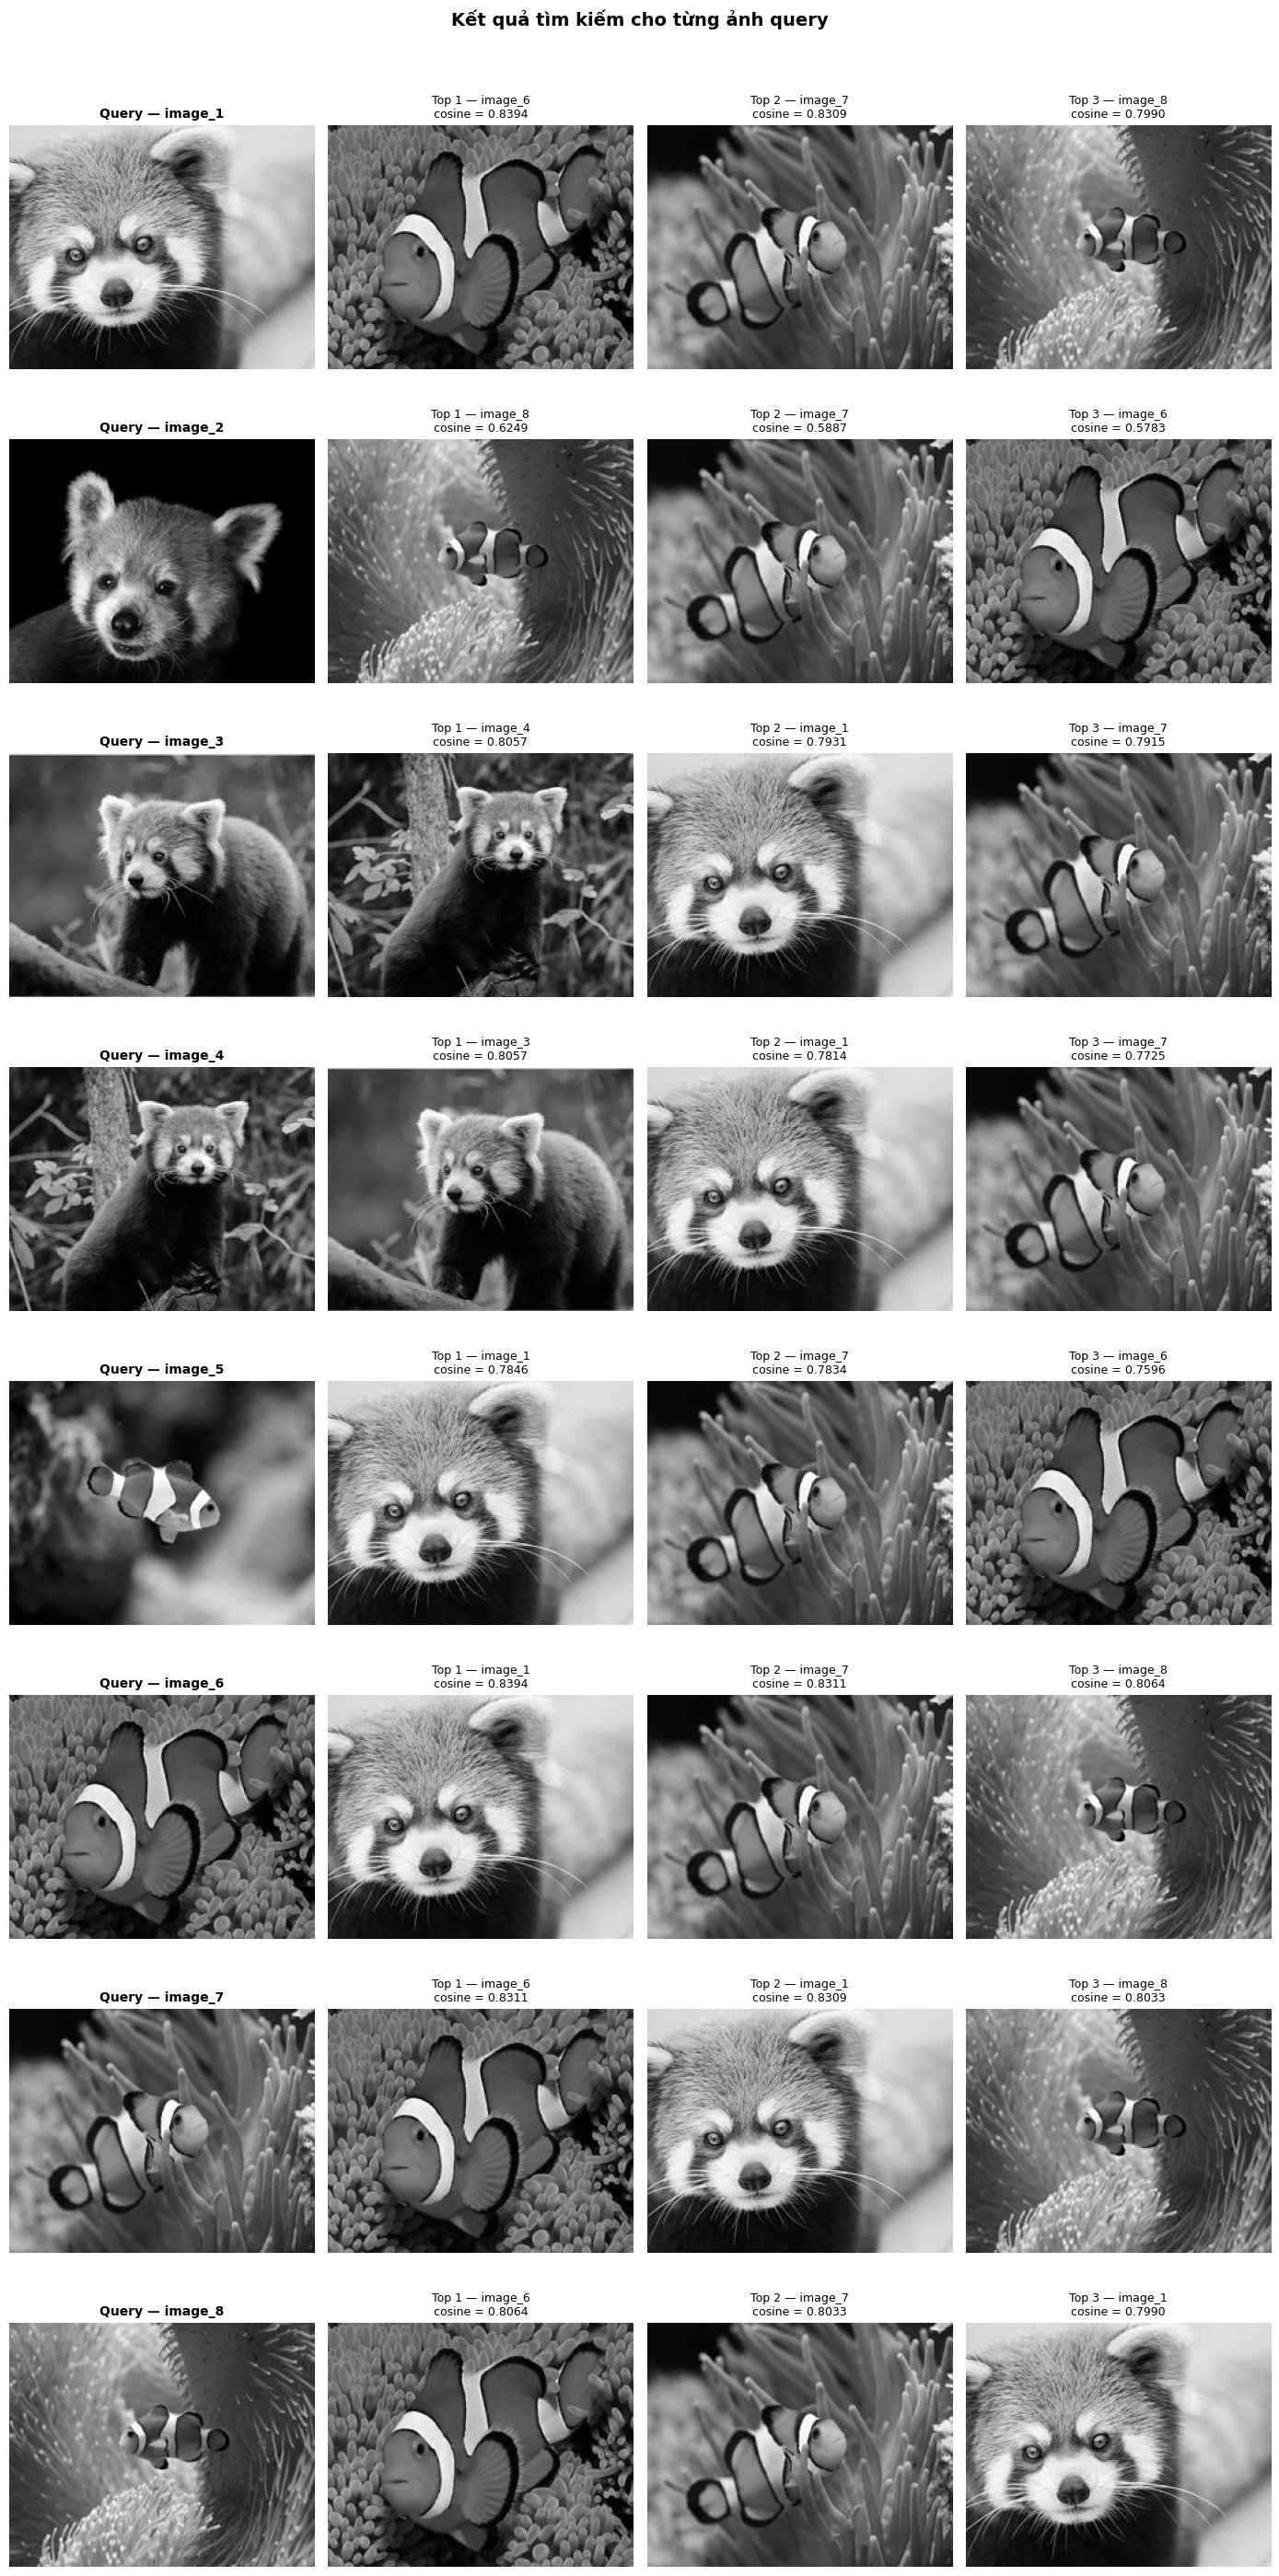

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 4, figsize=(14, 28))

for query_idx in range(8):
    indices, scores = search(X[query_idx], top_k=3)

    # ── Query ────────────────────────────────────────────────────────
    axes[query_idx, 0].imshow(X[query_idx].reshape(200, 250), cmap="gray")
    axes[query_idx, 0].set_title(f"Query — image_{query_idx + 1}", fontsize=10, fontweight="bold")
    axes[query_idx, 0].axis("off")
    for spine in axes[query_idx, 0].spines.values():
        spine.set_edgecolor("#4A90D9")
        spine.set_linewidth(3)
        spine.set_visible(True)

    # ── Top-k kết quả ────────────────────────────────────────────────
    for rank, (idx, score) in enumerate(zip(indices, scores), 1):
        axes[query_idx, rank].imshow(X[idx].reshape(200, 250), cmap="gray")
        axes[query_idx, rank].set_title(
            f"Top {rank} — image_{idx + 1}\ncosine = {score:.4f}", fontsize=9
        )
        axes[query_idx, rank].axis("off")

plt.suptitle("Kết quả tìm kiếm cho từng ảnh query", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# BÀI 2: Biến đổi tuyến tính & SVD

# 1. BIẾN ĐỔI TUYẾN TÍNH
Phép biến đổi tuyến tính thực chất là phép nhân ma trận đối với tập hợp các vector tọa độ.

- Ma trận R thực hiện phép nội suy góc, làm thay đổi hướng (xoay 45 độ) của vật thể trên không gian 2D mà không làm biến dạng tỷ lệ gốc.
- Ma trận S thực hiện phép tinh chỉnh tỷ lệ (scaling), làm biến dạng kích thước của vật thể trên các trục tương ứng (ở ví dụ này là kéo giãn trục X 2 lần, trục Y 0.5 lần).

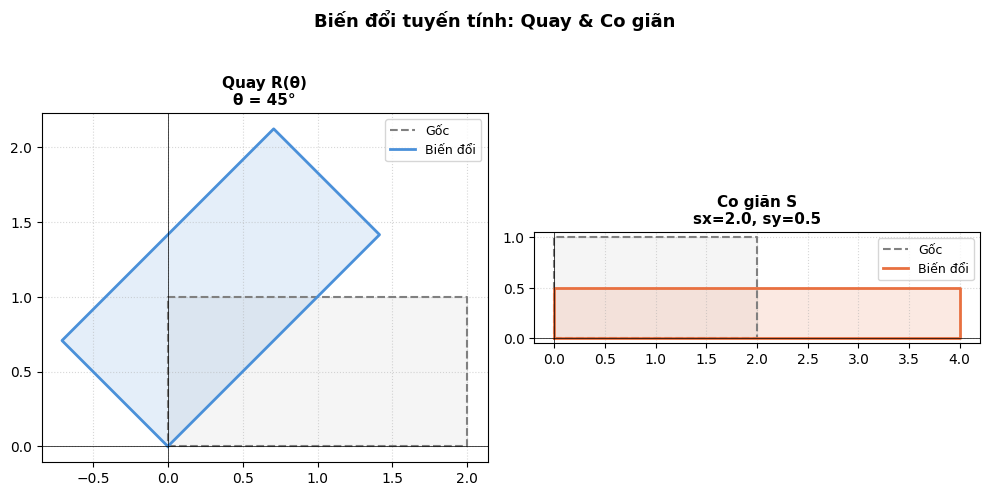

Ma trận quay R(45°):
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Ma trận co giãn S:
[[2.  0. ]
 [0.  0.5]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

#  Ma trận quay R(θ) 
theta = np.radians(45)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

#  Ma trận co giãn S 
sx, sy = 2.0, 0.5
S = np.array([
    [sx, 0],
    [0, sy]
])

# Tọa độ hình chữ nhật gốc 
rect = np.array([
    [0, 0],
    [2, 0],
    [2, 1],
    [0, 1],
    [0, 0]
]).T                        # shape (2, 5)

rect_scaled  = S @ rect
rect_rotated = R @ rect

#  Vẽ trước / sau 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

configs = [
    (rect_rotated, f"Quay R(θ)\nθ = 45°",          "#4A90D9"),
    (rect_scaled,  f"Co giãn S\nsx={sx}, sy={sy}", "#E87040")
]

for ax, (transformed, title, color) in zip(axes, configs):
    ax.plot(*rect, color="gray", linewidth=1.5,
            linestyle="--", label="Gốc")
    ax.fill(rect[0], rect[1], alpha=0.08, color="gray")

    ax.plot(*transformed, color=color, linewidth=2, label="Biến đổi")
    ax.fill(transformed[0], transformed[1], alpha=0.15, color=color)

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_aspect("equal")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

plt.suptitle("Biến đổi tuyến tính: Quay & Co giãn", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── In ma trận ───────────────────────────────────────────────────────
print("Ma trận quay R(45°):")
print(np.round(R, 4))
print("\nMa trận co giãn S:")
print(S)

# 2. NÉN ẢNH BẰNG SVD

Kích thước ảnh gốc: 200 x 250
U  : (200, 200)
S  : (200,)  — tổng 200 singular values
Vt : (250, 250)

     k    Tỉ lệ nén   Sai số (rel)
-----------------------------------
     5       22.17x        0.1527
    20        5.54x        0.0839
    50        2.22x        0.0479


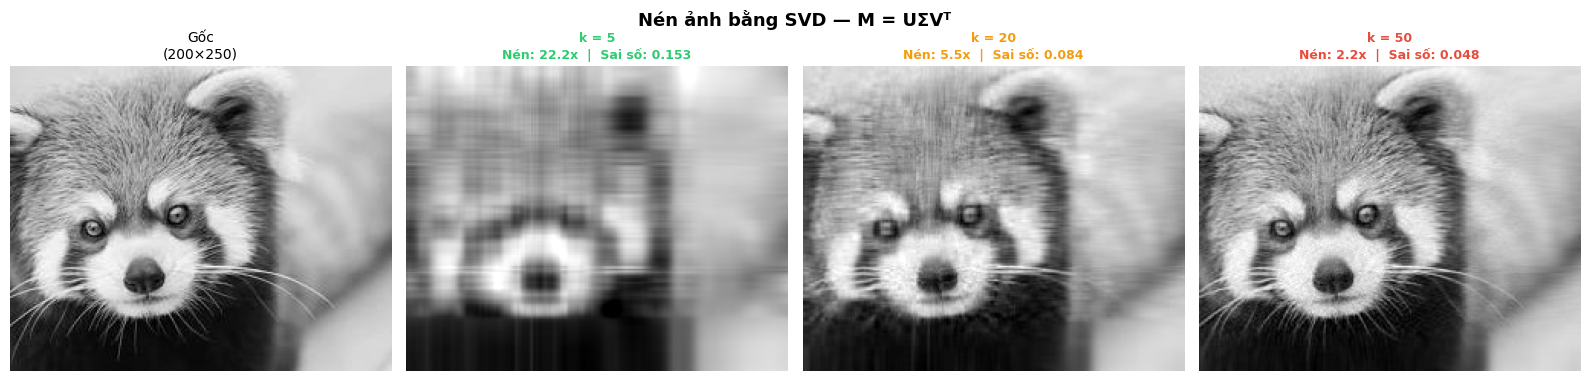

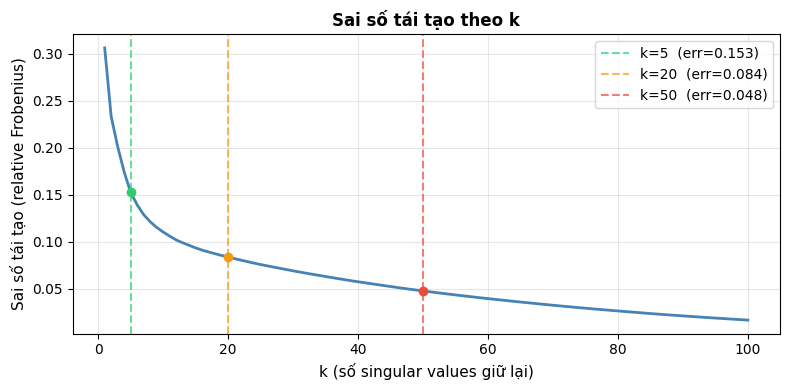

In [18]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chuyển sang grayscale
img1 = Image.open(r"C:\Users\AD\Downloads\image_1.jpg").convert("L")  # "L" = grayscale
M = np.array(img1, dtype=np.float64)               # shape: (H, W)
H, W = M.shape
print(f"Kích thước ảnh gốc: {H} x {W}")

# 2. Phân rã SVD
U, S, Vt = np.linalg.svd(M, full_matrices=True)

print(f"U  : {U.shape}")
print(f"S  : {S.shape}  — tổng {len(S)} singular values")
print(f"Vt : {Vt.shape}")

# 3. Ham tái tạo ảnh với k giá trị kì dị
def reconstruct(U, S, Vt, k):
    # Lấy k cột đầu của U, k singular values đầu, k hàng đầu của Vt
    U_k  = U[:, :k]          # (H, k)
    S_k  = np.diag(S[:k])    # (k, k)
    Vt_k = Vt[:k, :]         # (k, W)
    M_k  = U_k @ S_k @ Vt_k  # (H, W)
    # Clip về [0, 255]
    return np.clip(M_k, 0, 255)

# 4. Tái tạo với các giá trị k khác nhau
k_values = [5, 20, 50]
reconstructed = {k: reconstruct(U, S, Vt, k) for k in k_values}

# 5. Tính tỉ lệ nén và sai số tái tạo
def compression_ratio(H, W, k):
    original  = H * W
    compressed = k * (H + 1 + W)
    return original / compressed

def reconstruction_error(M_orig, M_k):
    return np.linalg.norm(M_orig - M_k, 'fro') / np.linalg.norm(M_orig, 'fro')

print(f"\n{'k':>6} {'Tỉ lệ nén':>12} {'Sai số (rel)':>14}")
print("-" * 35)
for k in k_values:
    cr  = compression_ratio(H, W, k)
    err = reconstruction_error(M, reconstructed[k])
    print(f"{k:>6} {cr:>11.2f}x {err:>13.4f}")

# 6. Vẽ ảnh gốc và ảnh tái tạo
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Nén ảnh bằng SVD — M = UΣVᵀ", fontsize=13, fontweight='bold')

# Ảnh gốc
axes[0].imshow(M, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f"Gốc\n({H}×{W})", fontsize=10)
axes[0].axis('off')

colors = ['#2ecc71', '#f39c12', '#e74c3c']
for ax, k, c in zip(axes[1:], k_values, colors):
    cr  = compression_ratio(H, W, k)
    err = reconstruction_error(M, reconstructed[k])
    ax.imshow(reconstructed[k], cmap='gray', vmin=0, vmax=255)
    ax.set_title(
        f"k = {k}\nNén: {cr:.1f}x  |  Sai số: {err:.3f}",
        fontsize=9, color=c, fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig("svd_compression.png", dpi=120, bbox_inches='tight')
plt.show()

# 7. Vẽ đồ thị sai số tái tạo theo k
k_range = list(range(1, min(101, len(S) + 1)))
errors  = [reconstruction_error(M, reconstruct(U, S, Vt, k)) for k in k_range]

plt.figure(figsize=(8, 4))
plt.plot(k_range, errors, color='steelblue', linewidth=2)
for k, c in zip(k_values, colors):
    err = reconstruction_error(M, reconstructed[k])
    plt.axvline(x=k, color=c, linestyle='--', alpha=0.7, label=f'k={k}  (err={err:.3f})')
    plt.scatter([k], [err], color=c, zorder=5)

plt.xlabel("k (số singular values giữ lại)", fontsize=11)
plt.ylabel("Sai số tái tạo (relative Frobenius)", fontsize=11)
plt.title("Sai số tái tạo theo k", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("svd_error_curve.png", dpi=120, bbox_inches='tight')
plt.show()

#### Đánh giá:
- Khi chọn $k = 5$, bức ảnh bị nén cực mạnh lên tới 22.2 lần, tuy nhiên chất lượng hình ảnh bị giảm sút nghiêm trọng, vỡ hạt và nhòe nhoẹt do sai số tái tạo cao nhất (15.3%).
- Khi $k = 20$, khi bức ảnh đạt được điểm cân bằng lý tưởng nhất: dung lượng giảm được 5.5 lần mà hình ảnh gấu trúc đỏ vẫn hiện lên rõ ràng, sắc nét vừa đủ với sai số chỉ còn 8.4%.
- Khi  $k = 50$, ảnh tái tạo đạt độ chính xác gần như tuyệt đối (sai số cực thấp 4.8%) và sắc nét như ảnh gốc, nhưng đổi lại hiệu quả tiết kiệm bộ nhớ giảm xuống đáng kể khi chỉ nén được 2.2 lần.
<p> => Đường cong sai số dốc xuống rất nhanh ở giai đoạn đầu rồi thoải dần, minh chứng rằng các thông tin cốt lõi nhất của bức ảnh tập trung chủ yếu ở vài chục thành phần đơn lẻ đầu tiên; việc tăng $k$ quá lớn sau đó sẽ làm tốn bộ nhớ lưu trữ mà không mang lại quá nhiều khác biệt về mặt thị giác.

#### Nhận xét:
##### 1. Về thực nghiệm nén ảnh bằng SVD
* **Mức $k=5$ (Nén quá cao):** Tiết kiệm dung lượng nhất (**22.2x**) nhưng ảnh bị vỡ hạt, mờ nhòe và không thể sử dụng thực tế.
* **Mức $k=20 \rightarrow 30$ (Ngưỡng chấp nhận được):** Là **điểm tối ưu**. Ảnh giữ được cấu trúc cốt lõi, rõ nét vừa đủ, sai số dưới 10% (**8.4%**) mà vẫn tiết kiệm được hơn 80% bộ nhớ (**nén 5.5x**).
* **Mức $k=50$ (Nén thấp):** Ảnh sắc nét như gốc (sai số chỉ **4.8%**) nhưng hiệu quả nén kém (chỉ giảm **2.2x**).
* **Bản chất đồ thị:** Sai số giảm rất nhanh ở giai đoạn đầu ($k$ nhỏ), chứng tỏ thông tin quan trọng nhất của bức ảnh đều tập trung ở vài chục giá trị đơn lẻ đầu tiên.

---

##### 2. Liên hệ với lĩnh vực AI (Trí tuệ nhân tạo)
* **Giảm chiều dữ liệu (Dimensionality Reduction):** Việc chọn hệ số $k$ nhỏ trong SVD chính là kỹ thuật loại bỏ thông tin dư thừa, nhiễu và trích xuất các đặc trưng cốt lõi (**Feature Extraction**).
* **Thuật toán PCA (Principal Component Analysis):** Công cụ giảm chiều dữ liệu kinh điển trong AI thực chất sử dụng lõi toán học từ SVD để giải quyết *"Lời nguyền bám chiều"* (Curse of Dimensionality), giúp mô hình chạy nhanh hơn và tránh lỗi học vẹt (**Overfitting**).